In [18]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\redga\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\redga\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import unicodedata
import re

from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

In [20]:
def data_preprocessing(df, column_name):
    try:
        from unidecode import unidecode as _unidecode
        def normalize_unidecode(text: str) -> str:
            return _unidecode(text)
    except Exception:
        def normalize_unidecode(text: str) -> str:
            return ''.join(
                c for c in unicodedata.normalize('NFKD', text)
                if not unicodedata.combining(c)
            )

    tokenizer = RegexpTokenizer(r"\w+")
    stemmer = SnowballStemmer("portuguese")

    STOPWORDS = set(stopwords.words("portuguese")) - {"nao", "nunca", "jamais"}

    def preprocess_text_pt_single(text: str) -> str:
        if not isinstance(text, str):
            return ""
        # 1. remover quebras e normalizar espaços
        text = re.sub(r'\s+', ' ', text.strip())
        # 2. remover HTML, URLs e emails
        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        text = re.sub(r'\S+@\S+', '', text)
        # 3. normalizar acentos (unidecode ou fallback)
        text = normalize_unidecode(text)
        # 4. remover tokens alfanuméricos tipo Q12, A1, C3
        text = re.sub(r'\b[a-zA-Z]*\d+[a-zA-Z]*\b', ' ', text)
        # 5. remover pontuação solta (mantém hífens e apóstrofos dentro de palavras se existirem)
        text = re.sub(r'[^\w\s\-\']', ' ', text)
        # 6. normalizar espaços de novo
        text = re.sub(r'\s+', ' ', text).strip()
        return text.lower()

    def preprocess_series_nltk(texts):
        results = []

        for text in texts:
            clean = preprocess_text_pt_single(text)

            tokens = [
                stemmer.stem(tok)
                for tok in tokenizer.tokenize(clean)
                if tok not in STOPWORDS
                and len(tok) > 2
                and not tok.isnumeric()
            ]

            results.append(" ".join(tokens))

        return results

    df['CLEAN_TEXT'] = preprocess_series_nltk(df[column_name])
    df['CLEAN_TEXT'] = (
        df['CLEAN_TEXT']
        .fillna("")        # remove NaN
        .astype(str)       # garante string
    )
    df.rename(columns={column_name: 'UNCLEAN_TEXT'}, inplace=True)
    df['UNCLEAN_TEXT'] = (
        df['UNCLEAN_TEXT']
        .fillna("")
        .astype(str)
    )
    return df

# (1) TweetEmotionsPTBR

In [21]:
df = pd.read_excel('../data/03_TweetEmotionsPTBR.xlsx')
df.drop(columns=['alegria',	'tristeza',	'raiva', 'medo', 'nojo', 'surpresa', 'confianca', 'antecipacao'], inplace=True)
print(df.shape)
df.head(3)

(12678, 2)


,texto,sentimento
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção
2,"A franquia continua ativa, com o desenvolvimen...",decepção


In [22]:
df.drop_duplicates(inplace=True)
df = data_preprocessing(df, 'texto')
df.rename(columns={"sentimento": 'EMOTION'}, inplace=True)
print(df.shape)
df.head(3)

(12420, 3)


,UNCLEAN_TEXT,EMOTION,CLEAN_TEXT
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria,jubil incalculavel ver tod quer prest ano pass...
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção,sapontamento senhor arranc coraca qualqu tip d...
2,"A franquia continua ativa, com o desenvolvimen...",decepção,franqu continu ativ desenvolv segund jog embor...


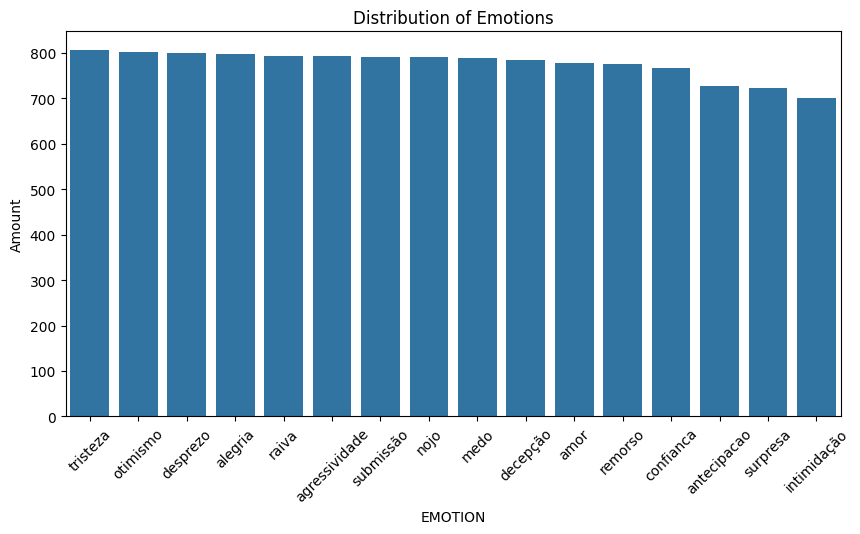

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df.EMOTION.value_counts().index, y=df.EMOTION.value_counts().values)
plt.xticks(rotation=45)
plt.ylabel("Amount")
plt.title("Distribution of Emotions")
plt.show()

In [24]:
df.to_csv("../data/treated/tweet_emotions_ptbr_treated.csv", index=False)

# (2) GoEmotions

In [25]:
df_1 = pd.read_csv('../data/05_goemotions_1_pt.csv')
df_2 = pd.read_csv('../data/05_goemotions_2_pt.csv')
df_3 = pd.read_csv('../data/05_goemotions_3_pt.csv')

df = pd.concat([df_1, df_2, df_3])
df.drop(columns=['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id'], inplace=True)

print(df.shape)
df.head(3)

(211225, 30)


,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,texto
0,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,Aquele jogo doeu.
1,True,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,>sexualidade não deve ser uma categoria de agr...
2,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,"Você faz certo, se você não se importa, então ..."


In [26]:
df.columns

Index(['example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance',
       'approval', 'caring', 'confusion', 'curiosity', 'desire',
       'disappointment', 'disapproval', 'disgust', 'embarrassment',
       'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
       'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse',
       'sadness', 'surprise', 'neutral', 'texto'],
      dtype='object')

In [27]:
df.drop_duplicates(inplace=True)
df = data_preprocessing(df, 'texto')
print(df.shape)
df.head(3)

(156007, 31)


,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,UNCLEAN_TEXT,CLEAN_TEXT
0,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,Aquele jogo doeu.,jog doeu
1,True,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,>sexualidade não deve ser uma categoria de agr...,sexual nao dev categor agrup torn diferent out...
2,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,"Você faz certo, se você não se importa, então ...",voc faz cert voc nao import enta fod


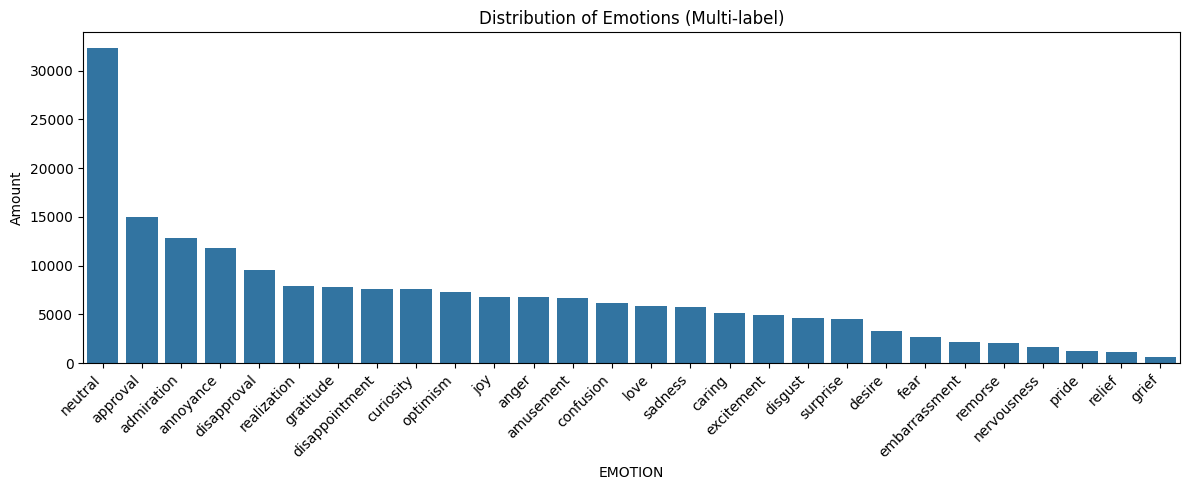

In [28]:
emotions = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

emotion_counts = df[emotions].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=emotion_counts.index,
    y=emotion_counts.values
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Amount")
plt.xlabel("EMOTION")
plt.title("Distribution of Emotions (Multi-label)")
plt.tight_layout()
plt.show()

In [29]:
df.to_csv("../data/treated/go_emotions_treated.csv", index=False)

# (3) PlayStoreReviews

In [30]:
df = pd.read_csv('../data/08_PlayStoreReviews.csv')
df.drop(columns=['reviewId', 'app_name'], inplace=True)
print(df.shape)
df.head(3)

(3011, 3)


,content,sentiment_polarity,sentiment
0,app shope razoá apes fácil utiliz apresent alg...,positive,sadness
1,app bem otimiz fácil visual produt ped rastrei...,positive,sadness
2,app bom prát fácil entend porém algum vend man...,positive,sadness


In [31]:
df.drop_duplicates(inplace=True)
df = data_preprocessing(df, 'content')
df.rename(columns={"sentiment": 'EMOTION'}, inplace=True)
df.rename(columns={"sentiment_polarity": 'SENTIMENT'}, inplace=True)
print(df.shape)
df.head(3)

(3011, 4)


,UNCLEAN_TEXT,SENTIMENT,EMOTION,CLEAN_TEXT
0,app shope razoá apes fácil utiliz apresent alg...,positive,sadness,app shop razo apes facil utiliz apresent algum...
1,app bem otimiz fácil visual produt ped rastrei...,positive,sadness,app bem otimiz facil visual produt ped rastr i...
2,app bom prát fácil entend porém algum vend man...,positive,sadness,app bom prat facil entend por algum vend mand ...


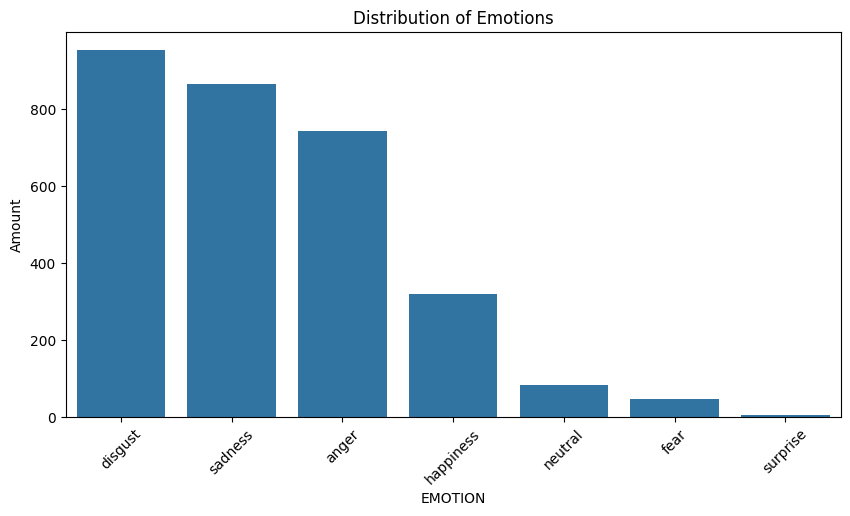

In [32]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df.EMOTION.value_counts().index, y=df.EMOTION.value_counts().values)
plt.xticks(rotation=45)
plt.ylabel("Amount")
plt.title("Distribution of Emotions")
plt.show()

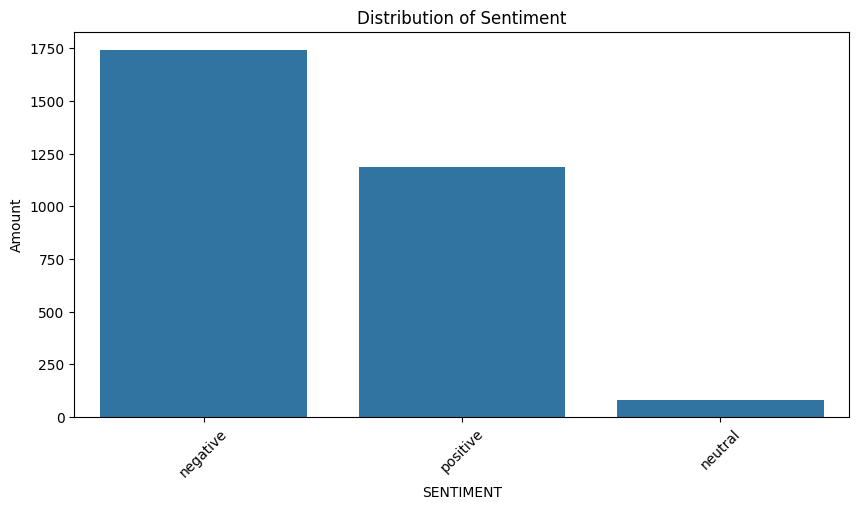

In [33]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df.SENTIMENT.value_counts().index, y=df.SENTIMENT.value_counts().values)
plt.xticks(rotation=45)
plt.ylabel("Amount")
plt.title("Distribution of Sentiment")
plt.show()

In [34]:
df.to_csv("../data/treated/play_store_reviews_treated.csv", index=False)